In [11]:
import pandas as pd
import geopandas
import folium
import geodatasets
import matplotlib.pyplot as plt
world = geopandas.read_file(geodatasets.get_path("naturalearth.land"))

In [12]:
df_smr = pd.read_csv('data_merge.csv')
df_smr = df_smr.loc[:, ("type", "latitude", "longitude", "capacity_mw")]
geometry_smr = geopandas.points_from_xy(df_smr.longitude, df_smr.latitude)
geo_smr_df = geopandas.GeoDataFrame(df_smr[["type", "latitude", "longitude", "capacity_mw"]], geometry=geometry_smr)
geo_smr_df.head()

,type,latitude,longitude,capacity_mw,geometry
0,Hydro,32.3220,65.1190,33.00,POINT (65.119 32.322)
1,Hydro,34.5560,69.4787,66.00,POINT (69.4787 34.556)
2,Hydro,34.6410,69.7170,100.00,POINT (69.717 34.641)
3,Hydro,34.4847,70.3633,11.55,POINT (70.3633 34.4847)
4,Hydro,35.9416,68.7100,6.00,POINT (68.71 35.9416)


In [16]:
gen_map = folium.Map(
    max_bounds=True, 
    min_lat=-70,
    max_lat=70,
    min_lon=-150,
    max_lon=150,
    control_scale=False, # Show a scale on the bottom of the map
    zoom_control=False, # shows zoom buttons by default
    tiles="CartoDB positron")

folium.CircleMarker(
            location=[36.972222, 122.52889],
            radius=2,
            color="Green",
            fill=True,
            fill_opacity=0.7,
            popup=folium.Popup(max_width=200)
        ).add_to(gen_map)

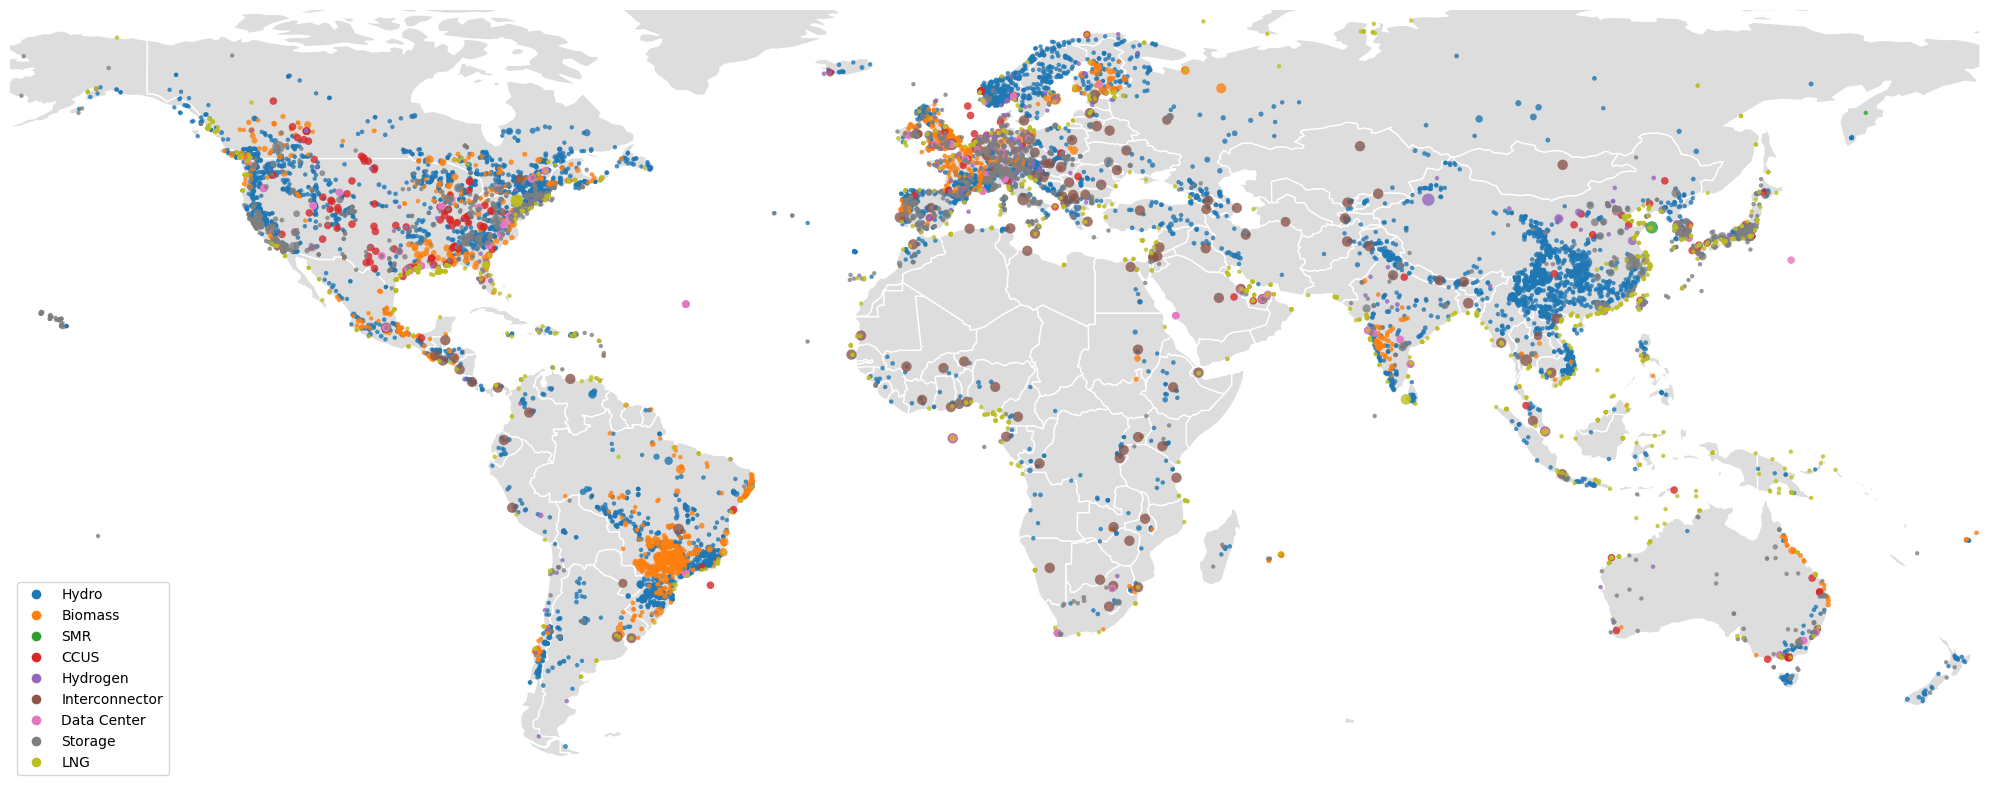

In [20]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ——— 1. 加载并准备数据 ———
df_smr = pd.read_csv('data_merge.csv')

# 定义一个安全的归一化函数，避免同一组中所有值都相同导致除以 0
def safe_normalize(x: pd.Series) -> pd.Series:
    rng = x.max() - x.min()
    if rng == 0:
        # 当组内所有 capacity_mw 相同，直接全部设为 1
        return pd.Series(1.0, index=x.index)
    else:
        return (x - x.min()) / rng

# 对每个 type 分组归一化 capacity_mw
df_smr['norm_capacity'] = (
    df_smr.groupby('type')['capacity_mw']
          .transform(safe_normalize)
)

# 映射归一化值到点的“面积”范围
min_area, max_area = 10, 80
df_smr['area'] = df_smr['norm_capacity'] * (max_area - min_area) + min_area
df_smr.loc[df_smr['type']=='CCUS','area'] = 30
df_smr.loc[df_smr['type']=='Data Center','area'] = 30

# ——— 2. 加载世界地图底图 ———
world_url = (
    "https://raw.githubusercontent.com/"
    "nvkelso/natural-earth-vector/master/geojson/"
    "ne_110m_admin_0_countries.geojson"
)
world = gpd.read_file(world_url)

# ——— 3. 绘图 ———
fig, ax = plt.subplots(figsize=(20, 10))

# 底图：灰色填充，白色边界
world.plot(ax=ax, color='#dddddd', edgecolor='white')

# 限制显示经纬度范围，不显示南北极
ax.set_xlim(-165, 180)
ax.set_ylim(-60, 75)

# 准备每个类别的颜色
types = df_smr['type'].unique()
cmap = plt.get_cmap('tab10')
color_map = {t: cmap(i % 10) for i, t in enumerate(types)}

# 按类别画散点
for t in types:
    sub = df_smr[df_smr['type'] == t]
    ax.scatter(
        sub['longitude'], sub['latitude'],
        s=sub['area'],            # 面积
        c=[color_map[t]],         # 颜色
        alpha=0.8,
        label=t,
        linewidths=0.0,
        edgecolors='k'
    )

# 自定义图例
legend_elems = [
    Line2D([0], [0], marker='o', color='w',
           label=t, markerfacecolor=color_map[t],
           markersize=8)
    for t in types
]
ax.legend(handles=legend_elems, loc='lower left')

# ax.set_title('World Map of SMR Capacities\n(normalized size by type)')
ax.set_axis_off()

plt.tight_layout()
plt.savefig('smr_world_map.pdf', dpi=900)
plt.show()
